# Formative 2 – PCA
## Part 1: Preparing the data and doing PCA by hand

**Data:** Rwanda Seasonal Agricultural Survey 2024, Season B (March–June 2024), from the National Institute of
Statistics of Rwanda (NISR). Each row is one farm plot. The columns say how the plot was farmed: erosion, anti-erosion
work, land consolidation, machines, hired labour and irrigation.

Most Rwandans work in farming, so knowing which practices tend to go together (for example, do irrigated plots also
use more hired labour?) is useful for deciding where to send support.

We only use `numpy` and `matplotlib`. The file is read with Python's built-in `csv` module.

**GitHub repo:** `<add link>`

In [15]:
import csv
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the data
`csv` gives us every value as text. An empty string means the value is missing.

In [16]:
with open("data/raw/sas_2024_seasonB_agricultural_practice.csv") as f:
    reader = csv.reader(f)
    header = next(reader)
    rows = [[value.strip() for value in row] for row in reader]

data = np.array(rows, dtype=object)
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 17261
Columns: 53


In [17]:
# Small helper so we can get a column by its name
def get(name):
    return data[:, header.index(name)]

## 2. Look at the columns
For each column we check whether it holds numbers or text, and how many values are missing.

In [18]:
def is_number(text):
    try:
        float(text)
        return True
    except ValueError:
        return False

numeric_cols = []
text_cols = []

for name in header:
    values = get(name)
    filled = values[values != ""]
    missing = len(values) - len(filled)

    if len(filled) > 0 and all(is_number(v) for v in filled):
        numeric_cols.append(name)
        kind = "numeric"
    else:
        text_cols.append(name)
        kind = "text"

    print(f"{name:<11} {kind:<8} missing: {missing}")

print("\nNumeric columns:", numeric_cols)
print("\nText columns:", text_cols)

id          numeric  missing: 0
Segment_ID  numeric  missing: 0
s1q1        text     missing: 0
s1q2        text     missing: 0
s1q3        text     missing: 0
s1q4        numeric  missing: 0
s1q6        numeric  missing: 0
s1q7        text     missing: 0
s1q8        text     missing: 544
s1q9        numeric  missing: 555
s1q14       text     missing: 0
s1q17       text     missing: 12124
s1q17_o     text     missing: 16986
s2q1        numeric  missing: 0
s2q2        numeric  missing: 0
s2q2_ha     numeric  missing: 0
s4q1        text     missing: 1
s4q2        text     missing: 1
s4q3        text     missing: 1881
s4q4        text     missing: 4135
s4q5        numeric  missing: 16254
s4q6        text     missing: 1
s4q7_1      text     missing: 16841
s4q7_2      text     missing: 17044
s4q7_3      text     missing: 17112
s4q7_4      text     missing: 17175
s4q8        text     missing: 1
s4q9        text     missing: 17030
s4q10_1     text     missing: 17124
s4q10_3     text     missi

## 3. Why are values missing?
In a survey, a lot of blanks are questions that were simply not asked. If a farmer says "No, I don't irrigate",
the next question "Is this plot irrigated?" is skipped. Let's check that.

In [19]:
def count_pairs(col_a, col_b):
    a = get(col_a)
    b = get(col_b)
    for x in sorted(set(a)):
        for y in sorted(set(b)):
            n = np.sum((a == x) & (b == y))
            if n > 0:
                print(f"  {col_a}={x or 'blank':<5}  {col_b}={y or 'blank':<5}  count={n}")

print("Irrigates any plot (s4q14) vs this plot irrigated (s4q15):")
count_pairs("s4q14", "s4q15")

print("\nAnti-erosion on any plot (s4q2) vs on this plot (s4q3):")
count_pairs("s4q2", "s4q3")

Irrigates any plot (s4q14) vs this plot irrigated (s4q15):
  s4q14=blank  s4q15=blank  count=1
  s4q14=No     s4q15=blank  count=14959
  s4q14=Yes    s4q15=No     count=1680
  s4q14=Yes    s4q15=Yes    count=621

Anti-erosion on any plot (s4q2) vs on this plot (s4q3):
  s4q2=blank  s4q3=blank  count=1
  s4q2=No     s4q3=blank  count=1880
  s4q2=No     s4q3=No     count=2
  s4q2=No     s4q3=Yes    count=1
  s4q2=Yes    s4q3=No     count=2284
  s4q2=Yes    s4q3=Yes    count=13093


In [20]:
# Who has no gender or age?
farmer_type = get("s1q7")
for t in sorted(set(farmer_type)):
    rows_of_type = farmer_type == t
    no_gender = np.sum(get("s1q8")[rows_of_type] == "")
    print(f"{t:<55} rows={rows_of_type.sum():<6} no gender={no_gender}")

Large scale  farmer as Coperative/Company/Association   rows=504    no gender=502
Large scale farmer as individual                        rows=479    no gender=0
Small Scale farmer as Coperative/Company/Association,   rows=53     no gender=42
Small scale farmer as individual                        rows=16225  no gender=0


**What we found and what we do about it**

* "This plot irrigated" is blank only when the household doesn't irrigate at all → fill with **No**.
* "Anti-erosion on this plot" is blank only when the farmer has none anywhere → fill with **No**.
* Irrigation cost and anti-erosion cost are blank when nothing was done → fill with **0**.
* "Machine used on this plot" is blank when the farm used no machines → fill with **No**.
* Gender and age are blank for cooperatives and companies (a group has no gender). Gender gets its own
  category, **Organisation**. Age is filled with the **median** age.
* One row has the whole farming section empty → we **drop** it.

**Columns we leave out:** ID numbers (`id`, `Segment_ID`, `s1q4`, `s1q6`, `s2q1`), the survey weight
(`plot_weight`), plot area in m² (same as area in hectares), a fully empty column (`s4q10_3`), interview details
(`s1q14`, `s1q17`, `s1q17_o`), district (30 values, province is enough), and follow-up questions that are
more than 97% blank.

## 4. Clean and encode

* Yes/No → 1/0
* Erosion level has an order (Very low → Severe) → 0, 1, 2, 3
* Province, stratum and gender have no order → one 0/1 column per category. We leave one category out
  (Kigali, hillside, Male) because the rest already tell us about it.
* Money and area values are very spread out (from 0 to millions of RWF), so we take `log(1 + x)`.

In [21]:
# Drop the row where the farming section is empty
data = data[get("s4q1") != ""]
print("Rows left:", len(data))

Rows left: 17260


In [22]:
def to_number(name, fill):
    values = get(name)
    return np.array([float(v) if v != "" else fill for v in values])

def yes_no(name):
    return (get(name) == "Yes").astype(float)   # blank counts as No

def one_hot(values, leave_out):
    names = []
    columns = []
    for category in sorted(set(values)):
        if category != leave_out:
            names.append(category)
            columns.append((values == category).astype(float))
    return names, columns

In [23]:
# Numbers
ages = to_number("s1q9", fill=np.nan)
age = np.where(np.isnan(ages), np.nanmedian(ages), ages)

area = np.log1p(to_number("s2q2_ha", fill=0))
labour_cost = np.log1p(to_number("s4q13", fill=0))
erosion_cost = np.log1p(to_number("s4q5", fill=0))
irrigation_cost = np.log1p(to_number("s4q19", fill=0))

# Erosion level: keep only the first words, e.g. "Very Low (Splash erosion)" -> "Very Low"
levels = {"Very Low": 0, "Low": 1, "Moderate": 2, "Severe": 3}
erosion_level = np.array([levels[v.split(" (")[0]] for v in get("s4q1")], dtype=float)

# Yes / No
anti_erosion = yes_no("s4q3")
consolidated = yes_no("s4q6")
machine = yes_no("s4q9")
irrigated = yes_no("s4q15")

# Categories
gender = np.where(get("s1q8") == "", "Organisation", get("s1q8"))
gender_names, gender_cols = one_hot(gender, leave_out="Male")

province_names, province_cols = one_hot(get("s1q1"), leave_out="Kigali")

short = {"Agricultural land on hillside": "hillside", "Agricultural land in marshland": "marshland",
         "Large Scale Farmer/LSF": "large farm", "Mixed": "mixed", "Rangeland": "rangeland"}
stratum = np.array([short[v] for v in get("s1q3")])
stratum_names, stratum_cols = one_hot(stratum, leave_out="hillside")

Note: we don't add a separate "large-scale farmer" column from `s1q7`. We checked it and it is exactly the same as
the "large farm" stratum column, so it would just be a copy.

In [24]:
feature_names = (["age", "area", "labour_cost", "erosion_cost", "irrigation_cost", "erosion_level",
                  "anti_erosion", "consolidated", "machine", "irrigated"]
                 + ["gender_" + n for n in gender_names]
                 + ["province_" + n for n in province_names]
                 + ["stratum_" + n for n in stratum_names])

X = np.column_stack([age, area, labour_cost, erosion_cost, irrigation_cost, erosion_level,
                     anti_erosion, consolidated, machine, irrigated]
                    + gender_cols + province_cols + stratum_cols)

print("Shape:", X.shape)
print("Missing values left:", np.isnan(X).sum())
print("Features:", feature_names)

Shape: (17260, 20)
Missing values left: 0
Features: ['age', 'area', 'labour_cost', 'erosion_cost', 'irrigation_cost', 'erosion_level', 'anti_erosion', 'consolidated', 'machine', 'irrigated', 'gender_Female', 'gender_Organisation', 'province_East', 'province_North', 'province_South', 'province_West', 'stratum_large farm', 'stratum_marshland', 'stratum_mixed', 'stratum_rangeland']


### Put everything on the same scale
Age is in years, costs are in log-RWF and the 0/1 columns are tiny in comparison. PCA looks for the biggest spread,
so without scaling, the column with the biggest numbers would win just because of its units.
We turn each column into a z-score: (value − mean) / standard deviation.

In [25]:
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

# Save the clean data for the rest of the group
with open("data/processed/sas_2024B_pca_ready.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(feature_names)
    writer.writerows(X.round(6))

---
# Task 1: PCA from scratch

### Step 1: Center the data (subtract the mean of each column)

In [26]:
X_centered = X_scaled - X_scaled.mean(axis=0)

### Step 2: Covariance matrix

In [27]:
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

print("Shape:", cov_matrix.shape)
print("Same as np.cov:", np.allclose(cov_matrix, np.cov(X_centered, rowvar=False)))

Shape: (20, 20)
Same as np.cov: True


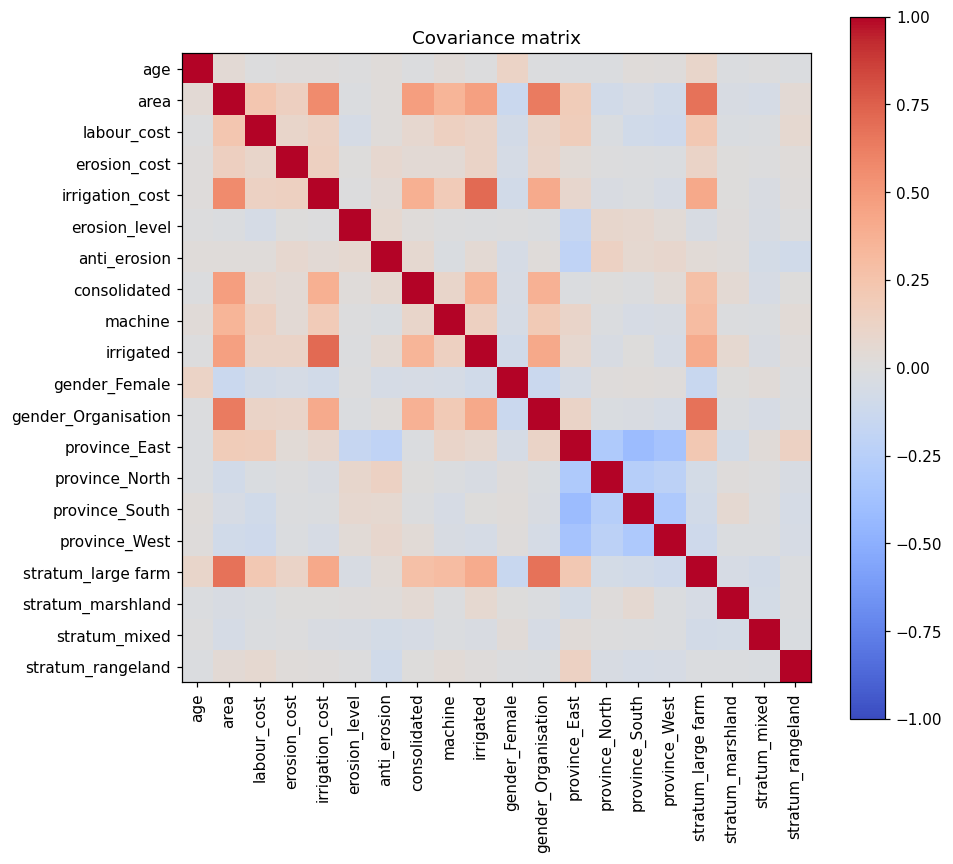

In [28]:
plt.figure(figsize=(9, 8))
plt.imshow(cov_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Covariance matrix")
plt.tight_layout()
plt.savefig("figures/covariance_matrix.png")
plt.show()

### Step 3: Eigenvalues and eigenvectors
`np.linalg.eigh` is made for symmetric matrices like this one.

In [29]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues:", eigenvalues.round(3))

Eigenvalues: [0.065 0.232 0.284 0.339 0.668 0.764 0.784 0.842 0.848 0.892 0.916 1.003 1.023 1.055 1.09  1.13  1.255 1.33  1.728
 3.752]


### Step 4: Sort from biggest to smallest

In [30]:
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

explained = eigenvalues / eigenvalues.sum()

for i in range(len(eigenvalues)):
    print(f"PC{i+1:<3} eigenvalue={eigenvalues[i]:.3f}   variance explained={explained[i]*100:.1f}%")

PC1   eigenvalue=3.752   variance explained=18.8%
PC2   eigenvalue=1.728   variance explained=8.6%
PC3   eigenvalue=1.330   variance explained=6.6%
PC4   eigenvalue=1.255   variance explained=6.3%
PC5   eigenvalue=1.130   variance explained=5.7%
PC6   eigenvalue=1.090   variance explained=5.4%
PC7   eigenvalue=1.055   variance explained=5.3%
PC8   eigenvalue=1.023   variance explained=5.1%
PC9   eigenvalue=1.003   variance explained=5.0%
PC10  eigenvalue=0.916   variance explained=4.6%
PC11  eigenvalue=0.892   variance explained=4.5%
PC12  eigenvalue=0.848   variance explained=4.2%
PC13  eigenvalue=0.842   variance explained=4.2%
PC14  eigenvalue=0.784   variance explained=3.9%
PC15  eigenvalue=0.764   variance explained=3.8%
PC16  eigenvalue=0.668   variance explained=3.3%
PC17  eigenvalue=0.339   variance explained=1.7%
PC18  eigenvalue=0.284   variance explained=1.4%
PC19  eigenvalue=0.232   variance explained=1.2%
PC20  eigenvalue=0.065   variance explained=0.3%


### Step 5: Pick the principal components
Here we keep 2 so we can draw them. (Task 2 chooses the number properly.)

In [31]:
k = 2
W = eigenvectors[:, :k]

print("Weight of each feature in PC1 and PC2:")
for name, w1, w2 in zip(feature_names, W[:, 0], W[:, 1]):
    print(f"  {name:<22} {w1:>7.3f} {w2:>7.3f}")

Weight of each feature in PC1 and PC2:
  age                      0.015   0.031
  area                     0.446   0.013
  labour_cost              0.159  -0.208
  erosion_cost             0.111   0.027
  irrigation_cost          0.382   0.135
  erosion_level           -0.026   0.269
  anti_erosion             0.018   0.366
  consolidated             0.282   0.209
  machine                  0.206  -0.096
  irrigated                0.360   0.153
  gender_Female           -0.104   0.014
  gender_Organisation      0.393   0.058
  province_East            0.141  -0.618
  province_North          -0.046   0.192
  province_South          -0.048   0.321
  province_West           -0.068   0.199
  stratum_large farm       0.409  -0.041
  stratum_marshland       -0.009   0.149
  stratum_mixed           -0.044  -0.111
  stratum_rangeland        0.022  -0.230


### Step 6: Project the data

In [32]:
X_pca = X_centered @ W

print("Before:", X_centered.shape)
print("After:", X_pca.shape)
print("Variance of PC1 and PC2:", X_pca.var(axis=0, ddof=1).round(3))

Before: (17260, 20)
After: (17260, 2)
Variance of PC1 and PC2: [3.752 1.728]


The variance of each new column matches its eigenvalue, which is what we expect.

The same steps as one function, so the rest of the group can reuse it:

In [33]:
def pca(X, k):
    X_centered = X - X.mean(axis=0)
    cov_matrix = (X_centered.T @ X_centered) / (X.shape[0] - 1)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    return X_centered @ eigenvectors[:, :k], eigenvalues

X_pca_check, _ = pca(X_scaled, 2)
print("Same result:", np.allclose(X_pca_check, X_pca))

Same result: True


---
## Plots: before and after PCA
Colours show the survey stratum (hillside, marshland, large farm, …).

In [34]:
colors = {"hillside": "gray", "mixed": "green", "marshland": "blue", "rangeland": "orange", "large farm": "red"}

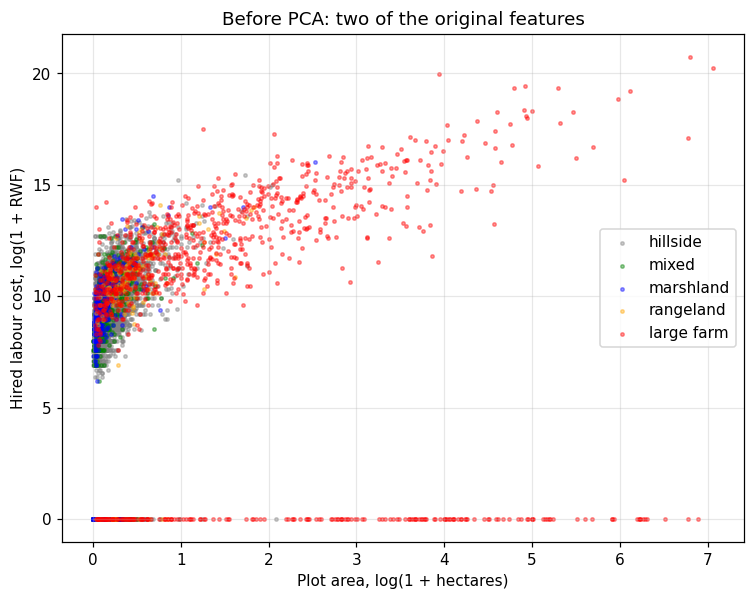

In [35]:
plt.figure(figsize=(8, 6))
for s, c in colors.items():
    rows = stratum == s
    plt.scatter(area[rows], labour_cost[rows], s=5, alpha=0.4, color=c, label=s)
plt.xlabel("Plot area, log(1 + hectares)")
plt.ylabel("Hired labour cost, log(1 + RWF)")
plt.title("Before PCA: two of the original features")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/before_pca.png")
plt.show()

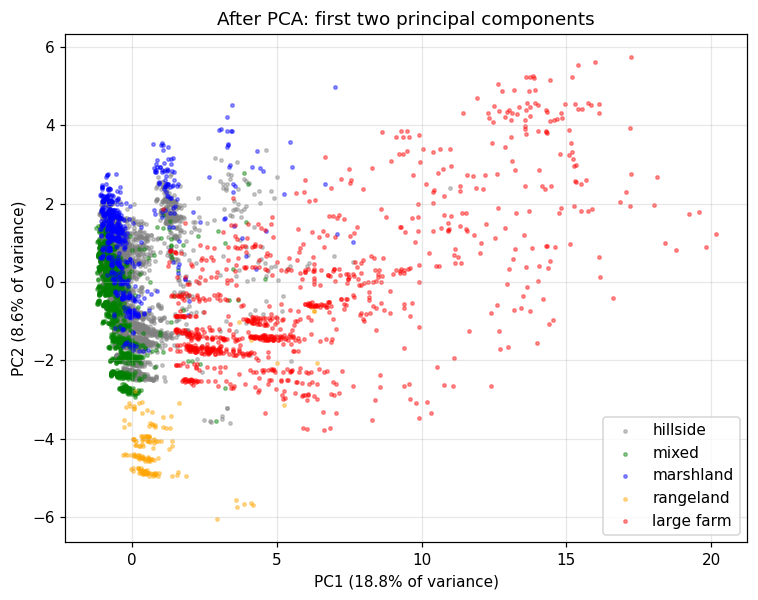

Points before: 17260   Points after: 17260


In [36]:
plt.figure(figsize=(8, 6))
for s, c in colors.items():
    rows = stratum == s
    plt.scatter(X_pca[rows, 0], X_pca[rows, 1], s=5, alpha=0.4, color=c, label=s)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% of variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% of variance)")
plt.title("After PCA: first two principal components")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/after_pca.png")
plt.show()

print("Points before:", len(X_scaled), "  Points after:", len(X_pca))

### What changed after PCA?
Before PCA, the plot showed only two of our 20 features: plot area and hired-labour cost. After PCA, each point combined information from all 20 features into two new scores, PC1 and PC2. We kept all 17,260 plots, but reduced the data from 20 columns to two.

The data were centred before projection, so the component scores have averages close to zero and the cloud sits around (0, 0). Each component’s variance equals its eigenvalue, and the components are sorted from largest to smallest. So PC1 has the greatest variance, **3.75**, compared with **1.73** for PC2. Together, PC1 and PC2 explain **27.4%** of the variation in the data.

Before PCA, most strata overlap, although large farms already spread out along plot area. After PCA, large farms separate more clearly, and rangeland stands apart vertically along PC2; hillside, marshland, and mixed plots still overlap. PC1 is associated with larger plots, irrigation-related features, large farms, and plots run by cooperatives or companies. Plots farther to the right tend to have higher values for these features. PC2 mainly separates Eastern plots from plots in provinces where erosion-control practices are more common. All 154 rangeland plots are in the Eastern Province, which helps explain their position along PC2.

This two-dimensional view leaves out **72.6%** of the variation in the original data. Age and the female-versus-male distinction have little influence on the first two components, while the cooperative/company category contributes noticeably to PC1.